In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/figure5/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [4]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset,species
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public,Homo sapiens
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public,Homo sapiens
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house,Homo sapiens
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public,Homo sapiens
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house,Homo sapiens
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house,Homo sapiens
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house,Homo sapiens
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public,Homo sapiens
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house,Homo sapiens


### FIGURE 5a

In [6]:
adata_hu = sc.read(data_dir + '_human_cochlea_late_2nd_trimester.h5ad')

In [7]:
adata_mu = sc.read(data_dir + 'mouse_cochlea_P25_P28_scVI_with_rawounts.h5ad')

In [8]:
#remove un-consistency cell-types
exclude_clusters = ['CCs','Chondrocytes','Erythrocytes','Melanocytes','Mesenchymal','Smooth_Muscle_Cells','pre-Osteoblasts']
adata_hu= adata_hu[~adata_hu.obs['cell_type'].isin(exclude_clusters), :]
adata_hu

View of AnnData object with n_obs × n_vars = 31370 × 39577
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gestation week (gw)', 'gender', '10xKit', 'sequencing', 'dataset', 'donor information', 'GSE ARCHIVE', 'percent_mito', 'n_counts', 'leiden_scanvi_1.2'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'genome-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-2', 'feature_types-2', 'genome-2', 'Gene-2', 'n_cells_by_counts-2', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'means-2', 'dispersions-2', 'dispersions_norm-2', 'n_cel

In [9]:
exclude_clusters = ['Scala_vestibuli_border_cells']
adata_mu= adata_mu[~adata_mu.obs['cell_type'].isin(exclude_clusters), :]
adata_mu

View of AnnData object with n_obs × n_vars = 16783 × 19593
    obs: 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'sequecing', 'leiden', 'louvain', 'cell_type'
    var: 'gene_ids', 'feature_types', 'Gene', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'mean-0', 'std-0', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'mean-1', 'std-1', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'means-2', 'dispersions-2', 'dispersions_norm-2', 'mean-2', 'std-2', 'mean_counts-3', 'pct_dropout_by_counts-3', 'total_counts-3', 'means-3', 'dispersions-3', 'dispersions_norm-3', 'mean-3', 'std-3', 'original_gene_symbol'
    uns: 'batch_colors', 'cell_type_colors', 'dendrogram_cell_type', 'hvg', 'leiden_scanvi_1.2', 'log1p', 'neighbors', 'pca', 'sequecing_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    layers

In [10]:
# keep both dataset cell number comparable
from sklearn.utils import resample
max_cells = 500


cells_to_keep = []


for cluster in adata_hu.obs['cell_type'].unique():
    
    cluster_cells = adata_hu.obs[adata_hu.obs['cell_type'] == cluster].index
    
    
    if len(cluster_cells) > max_cells:
        sampled_cells = resample(cluster_cells, 
                               replace=False, 
                               n_samples=max_cells, 
                               random_state=42)
        cells_to_keep.extend(sampled_cells)
    else:
        cells_to_keep.extend(cluster_cells)


downsampled_adata_hu = adata_hu[cells_to_keep, :].copy()
downsampled_adata_hu

AnnData object with n_obs × n_vars = 8697 × 39577
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gestation week (gw)', 'gender', '10xKit', 'sequencing', 'dataset', 'donor information', 'GSE ARCHIVE', 'percent_mito', 'n_counts', 'leiden_scanvi_1.2'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'genome-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-2', 'feature_types-2', 'genome-2', 'Gene-2', 'n_cells_by_counts-2', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'means-2', 'dispersions-2', 'dispersions_norm-2', 'n_cells-2', 'g

In [11]:
# keep both dataset cell number comparable
from sklearn.utils import resample
max_cells = 500


cells_to_keep = []


for cluster in adata_mu.obs['cell_type'].unique():
    
    cluster_cells = adata_mu.obs[adata_mu.obs['cell_type'] == cluster].index
    
    
    if len(cluster_cells) > max_cells:
        sampled_cells = resample(cluster_cells, 
                               replace=False, 
                               n_samples=max_cells, 
                               random_state=42)
        cells_to_keep.extend(sampled_cells)
    else:
        cells_to_keep.extend(cluster_cells)


downsampled_adata_mu = adata_mu[cells_to_keep, :].copy()
downsampled_adata_mu

AnnData object with n_obs × n_vars = 7597 × 19593
    obs: 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'sequecing', 'leiden', 'louvain', 'cell_type'
    var: 'gene_ids', 'feature_types', 'Gene', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'mean-0', 'std-0', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'mean-1', 'std-1', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'means-2', 'dispersions-2', 'dispersions_norm-2', 'mean-2', 'std-2', 'mean_counts-3', 'pct_dropout_by_counts-3', 'total_counts-3', 'means-3', 'dispersions-3', 'dispersions_norm-3', 'mean-3', 'std-3', 'original_gene_symbol'
    uns: 'batch_colors', 'cell_type_colors', 'dendrogram_cell_type', 'hvg', 'leiden_scanvi_1.2', 'log1p', 'neighbors', 'pca', 'sequecing_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    layers: 'counts

In [12]:
downsampled_adata_mu.obs['sample'] =downsampled_adata_mu.obs['batch']

In [13]:
# First verify the column exists and its current values
print("Columns in obs:", downsampled_adata_mu.obs.columns.tolist())
print("Current sample values:", downsampled_adata_mu.obs['sample'].unique())

# Define the mapping (adjust if your numbers should map differently)
sample_mapping = {
    0: "P25_1",
    1: "P25_2",
    2: "P28_1",
    3: "P28_2"
}

# Convert to string type first if needed, then apply mapping
downsampled_adata_mu.obs['sample'] = (
    downsampled_adata_mu.obs['sample']
    .astype(str)  # Convert to string to ensure mapping works
    .replace({str(k): v for k, v in sample_mapping.items()})
)

# Alternative robust approach if above doesn't work:
# downsampled_adata_mu.obs['sample'] = (
#     downsampled_adata_mu.obs['sample']
#     .map(sample_mapping)
#     .fillna(downsampled_adata_mu.obs['sample'])  # Keep original if no mapping
# )

# Verify the changes
print(downsampled_adata_mu.obs['sample'].value_counts())

Columns in obs: ['CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'sequecing', 'leiden', 'louvain', 'cell_type', 'sample']
Current sample values: ['3', '0', '1', '2']
Categories (4, object): ['0', '1', '2', '3']
sample
P28_2    2463
P28_1    1985
P25_1    1578
P25_2    1571
Name: count, dtype: int64


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvi

G:\Miniconda3\envs\omicverse\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
G:\Miniconda3\envs\omicverse\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
G:\Miniconda3\envs\omicverse\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
G:\Miniconda3\envs\omicverse\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
G:\Miniconda3\envs\omicverse\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing CSRDataset from `anndata.experimental` is deprecated. Import ann

In [ ]:
downsampled_adata_mu.obs['species']='mouse'
downsampled_adata_hu.obs['species']='human'

In [ ]:
downsampled_adata_mu.obs['cell_type_species'] = (
    downsampled_adata_mu.obs['cell_type'].astype(str) + '_' + downsampled_adata_mu.obs['species'].astype(str))

In [ ]:
downsampled_adata_hu.obs['cell_type_species'] = (
    downsampled_adata_hu.obs['cell_type'].astype(str) + '_' + downsampled_adata_hu.obs['species'].astype(str))

In [ ]:
adata_comparative = downsampled_adata_mu.concatenate(downsampled_adata_hu)
adata_comparative

In [ ]:
#change alternative procedure
sc.pp.normalize_total(adata_comparative, target_sum=1e4)
sc.pp.log1p(adata_comparative)

In [ ]:
adata_integration=adata_comparative.copy()

In [ ]:
sc.pp.highly_variable_genes(adata_integration)
sc.tl.pca(adata_integration)
sc.pp.neighbors(adata_integration)
sc.tl.umap(adata_integration)
adata_integration

In [ ]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_integration, color=['cell_type','sample'], wspace=0.5,size=10,ncols=1)

In [ ]:
label_key = "cell_type"
batch_key = "sample"

In [ ]:
sc.pp.filter_genes(adata_integration, min_cells=3)
adata_integration

In [ ]:
adata_integration.X = adata_integration.layers["counts"].copy()
sc.pp.normalize_total(adata_integration)
sc.pp.log1p(adata_integration)
adata_integration.layers["logcounts"] = adata_integration.X.copy()

In [ ]:
sc.pp.highly_variable_genes(adata_integration)
sc.tl.pca(adata_integration)
sc.pp.neighbors(adata_integration,n_neighbors=50)
sc.tl.umap(adata_integration,min_dist=0.8)
adata_integration

In [ ]:
sc.set_figure_params(figsize=(3,3),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_integration, color=[label_key, batch_key,], 
           wspace=0.65,size=20,ncols=1,
          save="_cross-species_unintegrated.pdf")

In [ ]:
sc.pp.highly_variable_genes(
    adata_integration, n_top_genes=1500, flavor="cell_ranger", batch_key=batch_key
)
adata_integration.var

In [ ]:
adata_hvg = adata_integration[:, adata_integration.var["highly_variable"]].copy()
adata_hvg
sc.tl.pca(adata_hvg,n_comps=30,use_highly_variable=True)

In [ ]:
adata_scvi=adata_hvg.copy()
scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key=batch_key)
def run_scvi(adata_hvg, batch_hv =batch_key, batch_scvi = batch_key, \
             cat_cov_scvi = ["species",'sample'], cont_cov_scvi = ["pct_counts_mt"], \
             include_genes = [], ):
    #adata_scvi = sc.AnnData(X = adata.layers['counts'].copy(), obs = adata.obs.copy(), var = adata.var.copy()
    
     scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key=batch_scvi, \
                             categorical_covariate_keys=cat_cov_scvi, \
                             continuous_covariate_keys=cont_cov_scvi)

     return(adata_scvi)

In [ ]:
adata_scvi = run_scvi(adata_hvg, batch_scvi = batch_key, cat_cov_scvi = ["species"],cont_cov_scvi = ["pct_counts_mt"]
             )# cat_cov_scvi = ["species"],
adata_scvi

In [ ]:
model_scvi = scvi.model.SCVI(adata_scvi,n_layers=3, n_latent=50)
model_scvi

In [ ]:
model_scvi.view_anndata_setup()

In [ ]:
max_epochs_scvi = np.min([round((20000 / adata_integration.n_obs) * 400), 400])
max_epochs_scvi

In [ ]:
model_scvi.train(max_epochs=400)

In [ ]:
adata_scvi.obsm["X_scVI"] = model_scvi.get_latent_representation()

In [ ]:
#Save latent space
pd.DataFrame(adata_scvi.obsm["X_scVI"]).to_csv('cross_species_all_XscVI_latent_space.csv')

In [ ]:
X_scVI = pd.read_csv('cross_species_all_XscVI_latent_space.csv', index_col=0)
adata_integration.obsm["X_scVI"] = X_scVI.to_numpy()

In [ ]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pp.neighbors(adata_integration, use_rep="X_scVI",n_neighbors=30)#n_neighbors=50
sc.tl.leiden(adata_integration,resolution=1.2,key_added = "leiden1.2")
sc.tl.umap(adata_integration,min_dist=0.8)#0.4
sc.pl.umap(adata_integration, color=['cell_type','sample','species','leiden1.2'
                             ], 
           wspace=0.35,ncols=1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram


df = adata_integration.obs.groupby(["cell_type_species", "leiden1.2"]).size().unstack(fill_value=0)
conf_mat = df / df.sum(axis=1).values[:, np.newaxis]


row_linkage = linkage(conf_mat, method='average', metric='cosine')
col_linkage = linkage(conf_mat.T, method='average', metric='cosine')


row_order = dendrogram(row_linkage, no_plot=True)['leaves']
col_order = dendrogram(col_linkage, no_plot=True)['leaves']
clustered_mat = conf_mat.iloc[row_order, col_order]


plt.figure(figsize=(12, 10))
sns.heatmap(
    clustered_mat,
    cmap="RdPu",
    square=True,
    linewidths=0,
    cbar_kws={"label": "Fraction"},
    xticklabels=True,
    yticklabels=True
)
plt.xlabel("Predicted (Leiden clusters)")
plt.ylabel("Observed (Cell Type + Species)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/Cross-species_analysis/CORRPLOT_HUMAN-MOUSE_COE_SCANVI_clustered.pdf', dpi=300)
plt.show()

In [ ]:
# Normally we would need to run scVI first but we have already done that here
# model_scvi = scvi.model.SCVI(adata_scvi) etc.
model_scanvi = scvi.model.SCANVI.from_scvi_model(
    model_scvi, labels_key=label_key, unlabeled_category="unlabelled"
)
print(model_scanvi)
model_scanvi.view_anndata_setup()

In [ ]:
max_epochs_scanvi = int(np.min([25, np.max([2, round(max_epochs_scvi / 3.0)])]))#25
model_scanvi.train(max_epochs=max_epochs_scanvi)

In [ ]:
adata_scanvi = adata_scvi.copy()
adata_scanvi.obsm["X_scANVI"] = model_scanvi.get_latent_representation()

In [ ]:
#Save latent space
pd.DataFrame(adata_scanvi.obsm["X_scANVI"]).to_csv('cross_species_all_XscANVI_latent_space.csv')

In [ ]:
X_scANVI = pd.read_csv('cross_species_all_XscANVI_latent_space.csv', index_col=0)
adata_integration.obsm["X_scANVI"] = X_scANVI.to_numpy()

In [ ]:
cluster_annotation = {
 'Basal_stria': 'Basal_stria',
    'Basal_stria/Spindle/Root_cells': 'Basal_stria',

    
    'Claudius/Inner-Outer_sulcus_cells': 'Claudius/Inner-Outer_sulcus_cells',
    
    'Deiters_cells': 'Deiters_cells/Pillar_cells',
    'Dieters_cells/Pillar_cells': 'Deiters_cells/Pillar_cells',
    'Endothelial': 'Endothelial_cells',
    
    'Fibrocytes': 'Fibrocytes',
    'GCs': 'GCs',
    'HCs': 'HCs',
    'IHCs': 'HCs',
    
    'Inner_border-phalangeal/Hensen_cells': 'Inner_border-phalangeal/Hensen_cells',
    'Interdental_cells': 'Interdental_cells',
    'Intermediate_stria': 'Intermediate_stria ',
    'Macrophages': 'Macrophages',
    'Marginal_stria': 'Marginal_stria',
    'Marginal_cells': 'Marginal_stria',
    'OHCs': 'HCs',
    
    'Osteoblasts': 'Osteocytes/Osteoblasts',
    'Osteocytes': 'Osteocytes/Osteoblasts',
    'Osteocytes/Osteoblasts': 'Osteocytes/Osteoblasts',
    'Pericytes/Endothelial_cells': 'Pericytes',
    
    'Pillar_cells': 'Deiters_cells/Pillar_cells',
    'Reissner_membrane': 'Reissner_membrane',
    'Root_cells': 'Root_cells',
    'SGNs': 'SGNs',
     'SGNs_1': 'SGNs',
     'SGNs_2': 'SGNs',
    'SS': 'SS',
    'SS_1': 'SS',
    'SS_2': 'SS',
    'Spindle_cells': 'Spindle_cells',

    'Tympanic_border_cells': 'Tympanic_border_cells',
    
    'pericytes': 'Pericytes',
   

    


}
adata_integration.obs['cell_type_final'] = adata_integration.obs['cell_type'].map(cluster_annotation).astype('category')

In [21]:
adata_integration=sc.read('cross_species_integration_final.h5ad')

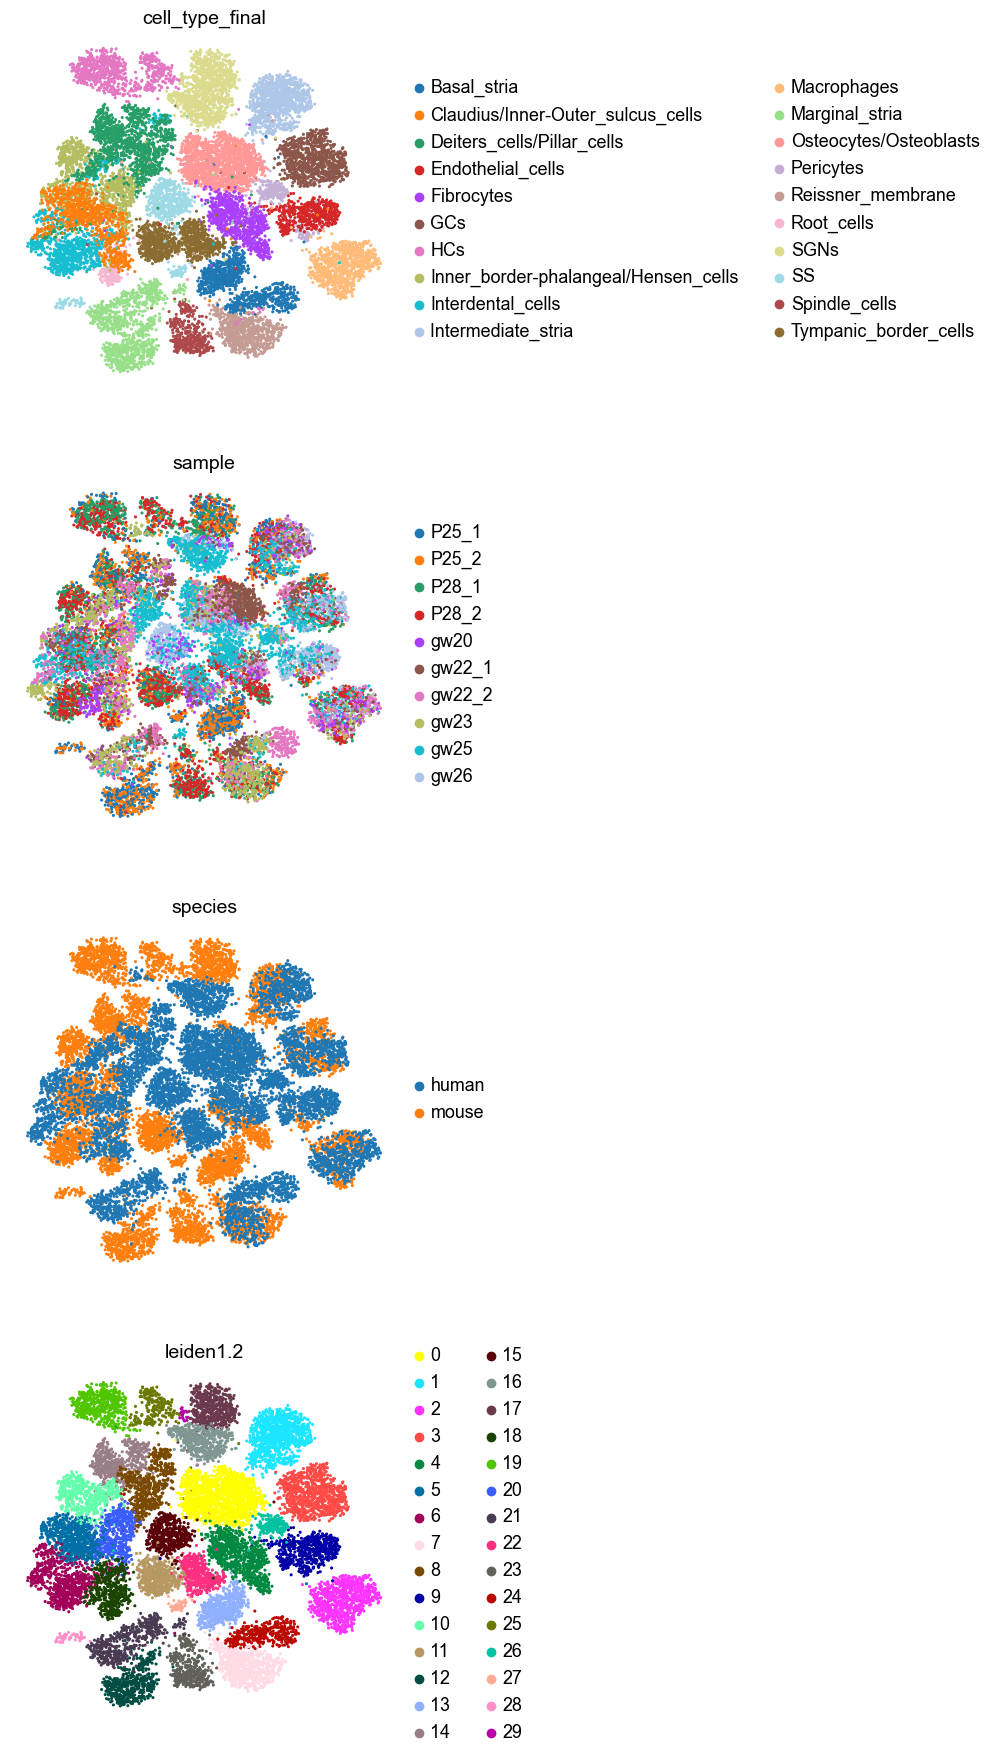

In [22]:
sc.set_figure_params(figsize=(4,5),frameon=False,dpi=50,dpi_save=600)
#sc.tl.umap(adata_integration,min_dist=1.2)#0.8
sc.pl.umap(adata_integration, color=['cell_type_final','sample','species',
                             'leiden1.2',], 
           wspace=0.35,ncols=1,size=20,
          #save="_cross-species_scANVI.pdf"
          )

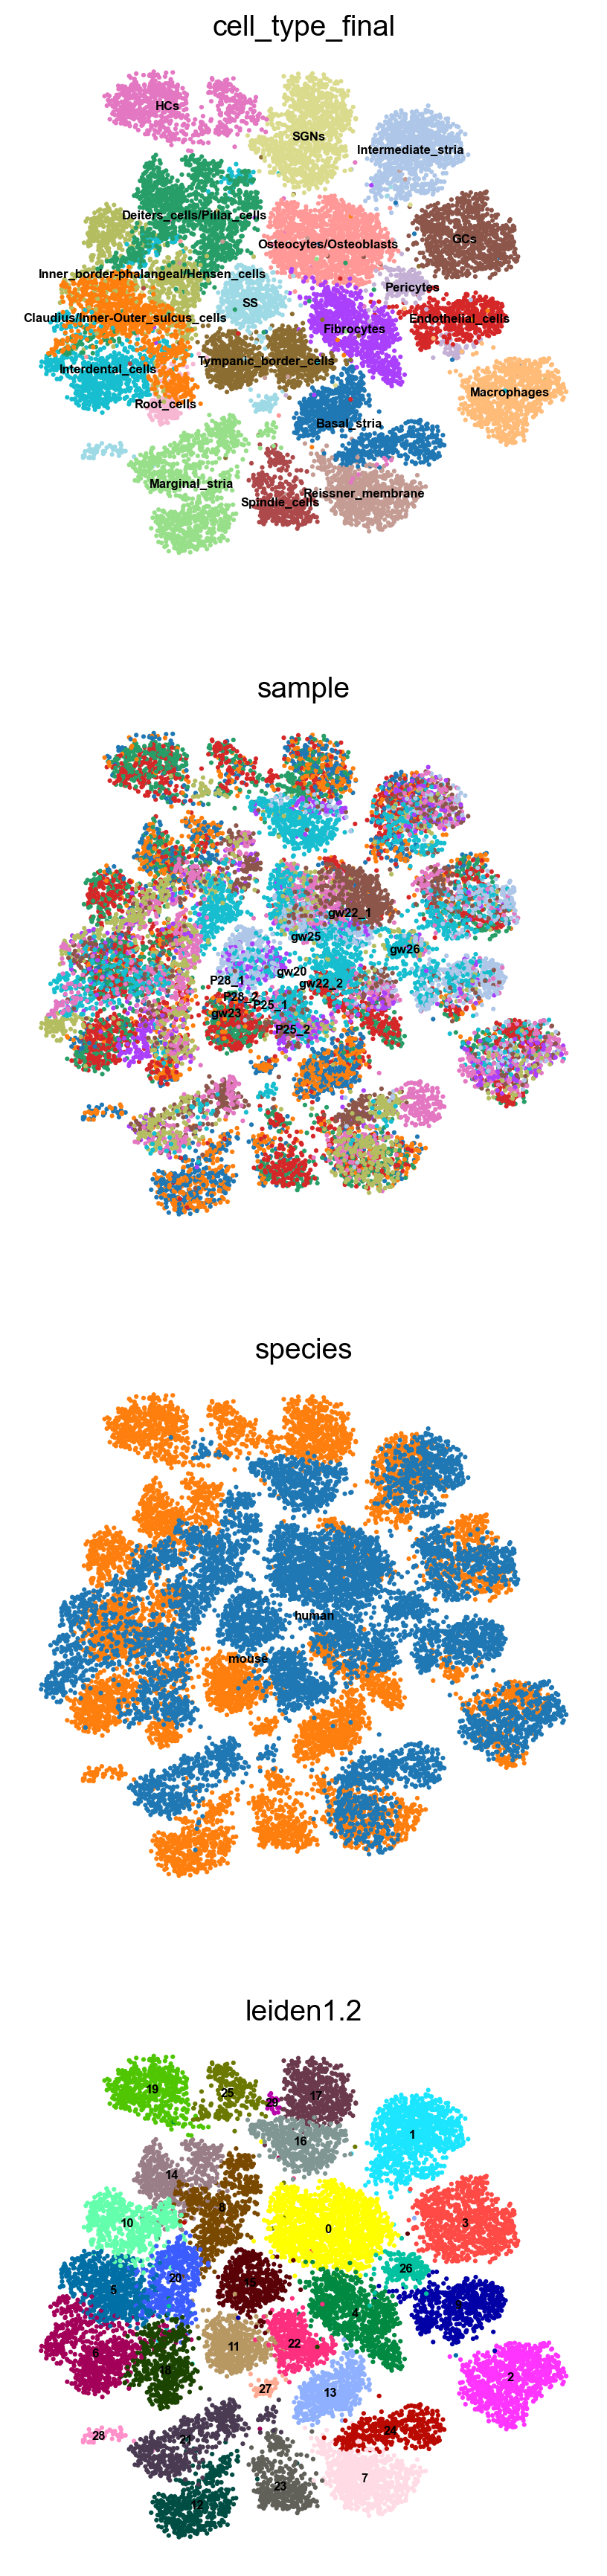

In [23]:
sc.set_figure_params(figsize=(4,5),frameon=False,dpi=100,dpi_save=600)
#sc.tl.umap(adata_integration,min_dist=1.2)#0.8
sc.pl.umap(adata_integration, color=['cell_type_final','sample','species',
                             'leiden1.2',], 
           wspace=0.35,ncols=1,size=20,legend_loc='on data',legend_fontsize=6,
          #save="_cross-species_scANVI_2.pdf"
          )

In [ ]:
cluster_annotation = {
 'Basal_stria': 'Lateral_WALL & SS',
    'Basal_stria/Spindle/Root_cells': 'Lateral_WALL & SS',

    
    'Claudius/Inner-Outer_sulcus_cells': 'Cochlear_epithelium',
    
    'Deiters_cells': 'Cochlear_epithelium',
    'Dieters_cells/Pillar_cells': 'Cochlear_epithelium',
    'Endothelial': 'Lateral_WALL & SS',
    
    'Fibrocytes': 'Lateral_WALL & SS',
    'GCs': 'Modiolus',
    'HCs': 'Cochlear_epithelium',
    'IHCs': 'Cochlear_epithelium',
    
    'Inner_border-phalangeal/Hensen_cells': 'Cochlear_epithelium',
    'Interdental_cells': 'Cochlear_epithelium',
    'Intermediate_stria': 'Lateral_WALL & SS',
    'Macrophages': 'Circulating & Others',
    'Marginal_stria': 'Lateral_WALL & SS',
    'Marginal_cells': 'Lateral_WALL & SS',
    'OHCs': 'Cochlear_epithelium',
    
    'Osteoblasts': 'Lateral_WALL & SS',
    'Osteocytes': 'Lateral_WALL & SS',
    'Osteocytes/Osteoblasts': 'Lateral_WALL & SS',
    'Pericytes/Endothelial_cells': 'Lateral_WALL & SS',
    
    'Pillar_cells': 'Cochlear_epithelium',
    'Reissner_membrane': 'Lateral_WALL & SS',
    'Root_cells': 'Lateral_WALL & SS',
    'SGNs': 'Modiolus',
     'SGNs_1': 'Modiolus',
     'SGNs_2': 'Modiolus',
    'SS': 'Lateral_WALL & SS',
    'SS_1': 'Lateral_WALL & SS',
    'SS_2': 'Lateral_WALL & SS',
    'Spindle_cells': 'Lateral_WALL & SS',

    'Tympanic_border_cells': 'Lateral_WALL & SS',
    
    'pericytes': 'Lateral_WALL & SS',
   

    


}
adata_integration.obs['region'] = adata_integration.obs['cell_type'].map(cluster_annotation).astype('category')

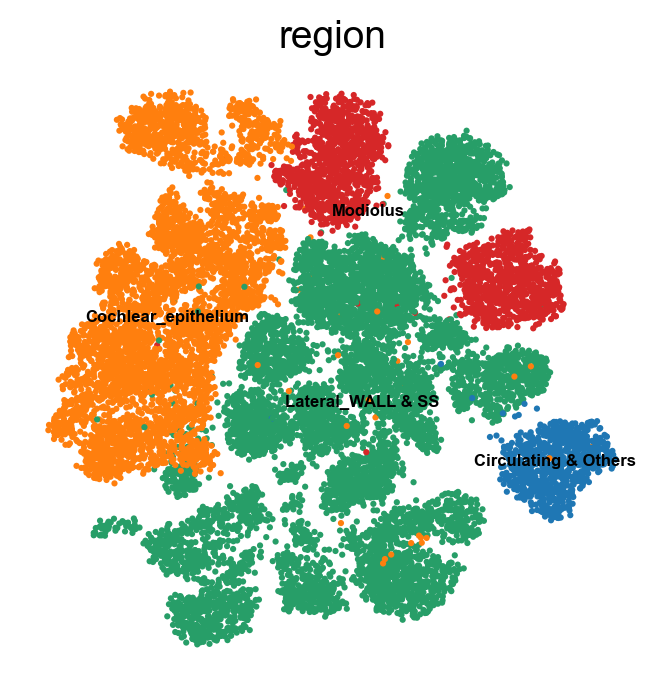

In [26]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=100,dpi_save=600)
#sc.tl.umap(adata_integration,min_dist=1.2)#0.8
sc.pl.umap(adata_integration, color=['region',], 
           wspace=0.35,ncols=1,size=20,legend_loc='on data',legend_fontsize=6,
          save="_cross-species_scANVI_region2.pdf"
          )

In [ ]:
adata_integration.obs['cell_type_species'] = (
    adata_integration.obs['cell_type_final'].astype(str) + '_' + adata_integration.obs['species'].astype(str))

### FIGURE 5b/e

In [25]:
import scvelo as scv
scv.set_figure_params(figsize=(4,4))
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'species')

Text(0.5, 1.0, 'cell type final')

Text(0.5, 1.0, 'IKZF2')

Text(0.5, 1.0, 'GATA3')

Text(0.5, 1.0, 'RORB')

Text(0.5, 1.0, 'ESRRG')

Text(0.5, 1.0, 'PROX1')

Text(0.5, 1.0, 'ZEB2')

Text(0.5, 1.0, 'TBX2')

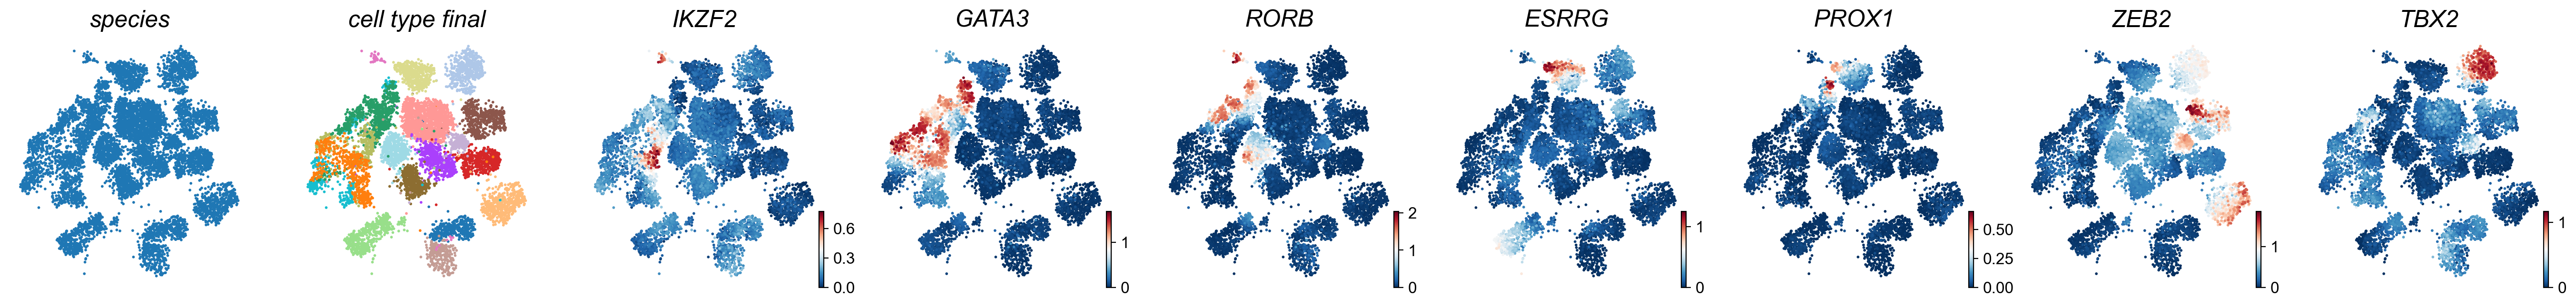

In [27]:
scv.set_figure_params(figsize=(3.8,3.5))
adata_subset_human = adata_integration[adata_integration.obs['species'] == 'human']
axs=scv.pl.umap(adata_subset_human, color=['species','cell_type_final',
               'IKZF2',"GATA3","RORB","ESRRG","PROX1",'ZEB2','TBX2'], smooth=True,show=False,)
for ax in axs:
    ax.set_title(ax.get_title(),style="italic",fontsize=18)
plt.savefig(data_dir+"figures/figure5/umap_cross-species_scANVI_2_human.pdf",dpi=600)

Text(0.5, 1.0, 'species')

Text(0.5, 1.0, 'cell type final')

Text(0.5, 1.0, 'IKZF2')

Text(0.5, 1.0, 'GATA3')

Text(0.5, 1.0, 'RORB')

Text(0.5, 1.0, 'ESRRG')

Text(0.5, 1.0, 'PROX1')

Text(0.5, 1.0, 'ZEB2')

Text(0.5, 1.0, 'TBX2')

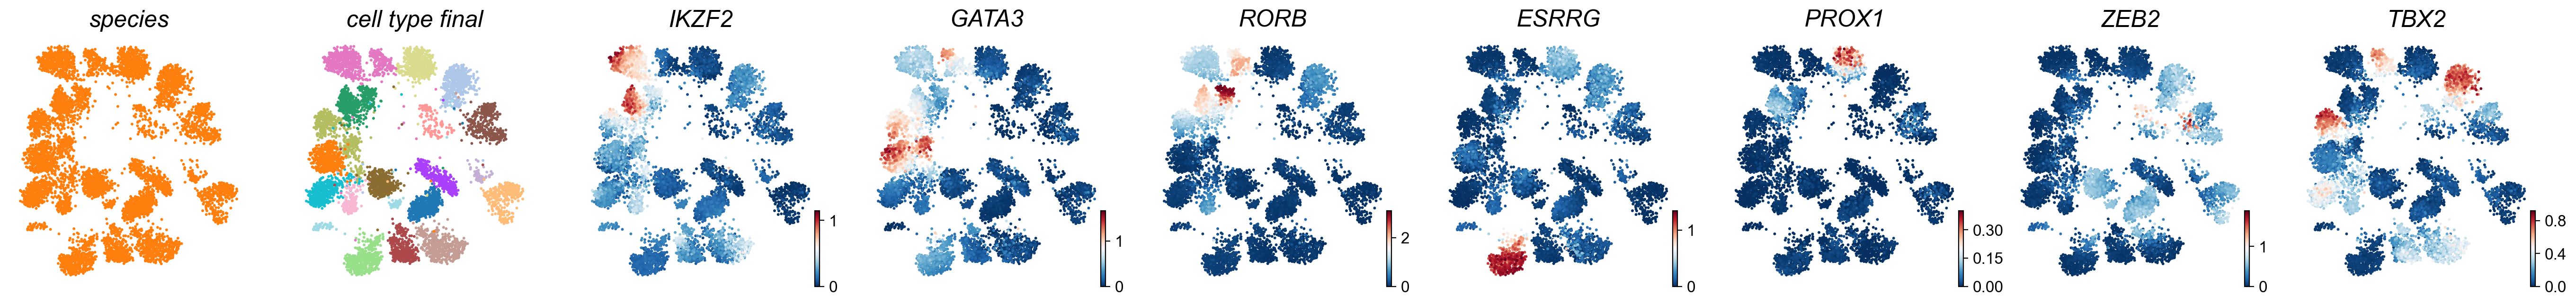

In [28]:
scv.set_figure_params(figsize=(3.8,3.5))
adata_subset_mouse = adata_integration[adata_integration.obs['species'] == 'mouse']
axs=scv.pl.umap(adata_subset_mouse, color=['species','cell_type_final',
               'IKZF2',"GATA3","RORB","ESRRG","PROX1",'ZEB2','TBX2'], smooth=True,show=False,)
for ax in axs:
    ax.set_title(ax.get_title(),style="italic",fontsize=18)
plt.savefig(data_dir+"figures/figure5/umap_cross-species_scANVI_2_mouse.pdf",dpi=600)

### FIGURE 5c/f

In [30]:
#remove un-consistency cell-types
exclude_clusters = ['CCs','Chondrocytes','Erythrocytes','Melanocytes','Mesenchymal','Smooth_Muscle_Cells','pre-Osteoblasts','pericytes']
adata_hu= adata_hu[~adata_hu.obs['cell_type'].isin(exclude_clusters), :]
adata_hu

View of AnnData object with n_obs × n_vars = 31172 × 39577
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gestation week (gw)', 'gender', '10xKit', 'sequencing', 'dataset', 'donor information', 'GSE ARCHIVE', 'percent_mito', 'n_counts', 'leiden_scanvi_1.2'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'genome-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-2', 'feature_types-2', 'genome-2', 'Gene-2', 'n_cells_by_counts-2', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'means-2', 'dispersions-2', 'dispersions_norm-2', 'n_cel

In [31]:
cluster_annotation = {
 'Basal_stria': 'Basal_stria',
    'Basal_stria/Spindle/Root_cells': 'Basal_stria',

    
    'Claudius/Inner-Outer_sulcus_cells': 'Claudius/Inner-Outer_sulcus_cells',
    
    'Deiters_cells': 'Deiters_cells/Pillar_cells',
    
    'Endothelial': 'Endothelial_cells',
    
    'Fibrocytes': 'Fibrocytes',
    'GCs': 'GCs',
    'HCs': 'HCs',
   
    
    'Inner_border-phalangeal/Hensen_cells': 'Inner_border-phalangeal/Hensen_cells',
    'Interdental_cells': 'Interdental_cells',
    'Intermediate_stria': 'Intermediate_stria ',
    'Macrophages': 'Macrophages',
    'Marginal_stria': 'Marginal_stria',
    
    
    
    'Osteoblasts': 'Osteocytes/Osteoblasts',
    'Osteocytes': 'Osteocytes/Osteoblasts',
    'Osteocytes/Osteoblasts': 'Osteocytes/Osteoblasts',
   
    
    'Pillar_cells': 'Deiters_cells/Pillar_cells',
    'Reissner_membrane': 'Reissner_membrane',
   
    'SGNs': 'SGNs',
    
    'SS': 'SS',
   
  
    'Tympanic_border_cells': 'Tympanic_border_cells',
    
  
   


}
adata_hu.obs['cell_type_pyscenic'] = adata_hu.obs['cell_type'].map(cluster_annotation).astype('category')

In [32]:
sc.pp.filter_genes(adata_hu, min_cells=1)
adata_hu

AnnData object with n_obs × n_vars = 31172 × 39490
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gestation week (gw)', 'gender', '10xKit', 'sequencing', 'dataset', 'donor information', 'GSE ARCHIVE', 'percent_mito', 'n_counts', 'leiden_scanvi_1.2', 'cell_type_pyscenic'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'genome-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-2', 'feature_types-2', 'genome-2', 'Gene-2', 'n_cells_by_counts-2', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'means-2', 'dispersions-2', 'dispersions_n

In [33]:
from sklearn.utils import resample
max_cells = 100


cells_to_keep = []


for cluster in adata_hu.obs['cell_type_pyscenic'].unique():
    
    cluster_cells = adata_hu.obs[adata_hu.obs['cell_type_pyscenic'] == cluster].index
    
    
    if len(cluster_cells) > max_cells:
        sampled_cells = resample(cluster_cells, 
                               replace=False, 
                               n_samples=max_cells, 
                               random_state=42)
        cells_to_keep.extend(sampled_cells)
    else:
        cells_to_keep.extend(cluster_cells)


downsampled_adata = adata_hu[cells_to_keep, :].copy()
downsampled_adata

AnnData object with n_obs × n_vars = 1639 × 39490
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gestation week (gw)', 'gender', '10xKit', 'sequencing', 'dataset', 'donor information', 'GSE ARCHIVE', 'percent_mito', 'n_counts', 'leiden_scanvi_1.2', 'cell_type_pyscenic'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'genome-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-2', 'feature_types-2', 'genome-2', 'Gene-2', 'n_cells_by_counts-2', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'means-2', 'dispersions-2', 'dispersions_no

In [34]:
#change alternative procedure
sc.pp.normalize_total(downsampled_adata, target_sum=1e4)
sc.pp.log1p(downsampled_adata)

In [35]:
# for IKZF2 AND GATA3 ==HC AND SC
# re-annotate
cluster_annotation = {
 'Basal_stria': 'Other_cell_types',
    'Claudius/Inner-Outer_sulcus_cells': 'SCs',
    'Deiters_cells/Pillar_cells': 'SCs',
    'Fibrocytes': 'Other_cell_types',
    'GCs': 'Other_cell_types',
  
    'Inner_border-phalangeal/Hensen_cells': 'SCs',
    'Interdental_cells': 'SCs',
    'Intermediate_stria': 'Other_cell_types',
    'Macrophages': 'Other_cell_types',
 
    'Marginal_stria': 'Other_cell_types',
    'HCs': 'HCs',

    'Osteocytes/Osteoblasts': 'Other_cell_types',
    'Endothelial_cells': 'Other_cell_types',
    
    'Reissner_membrane': 'Other_cell_types',
   
  
     'SGNs': 'Other_cell_types',


    'SS': 'Other_cell_types',


    'Tympanic_border_cells': 'Other_cell_types',
}
downsampled_adata.obs['cell_type_for_ikzf2_gata3'] = downsampled_adata.obs['cell_type_pyscenic'].map(cluster_annotation).astype('category')

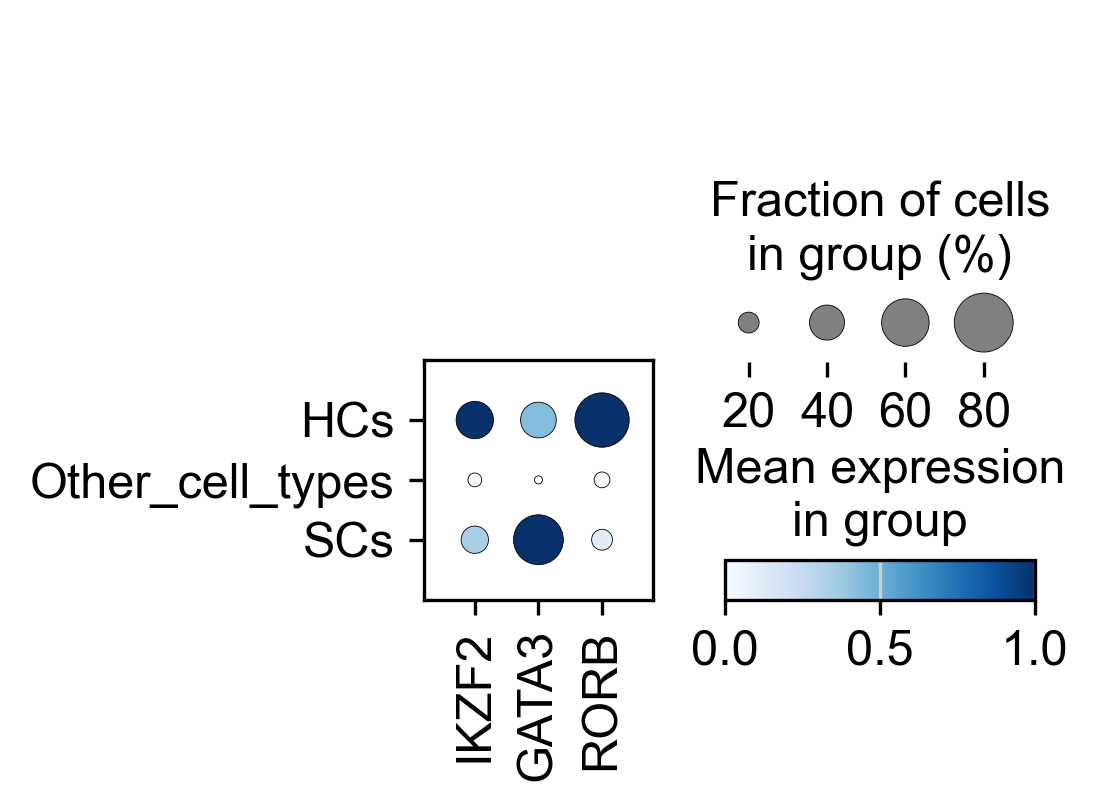

In [36]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(downsampled_adata,['IKZF2','GATA3','RORB'],
              groupby='cell_type_for_ikzf2_gata3',
              cmap='Blues',standard_scale='var',save='HUMAN_GATA3_IKZF2_RORB.pdf'
        )

In [37]:
# for prox1 ==sgn AND dc_pc
# re-annotate
cluster_annotation = {
 'Basal_stria': 'Other_cell_types',
    'Claudius/Inner-Outer_sulcus_cells': 'Other_cell_types',
    'Deiters_cells/Pillar_cells': 'DC_PCs',
    'Fibrocytes': 'Other_cell_types',
    'GCs': 'Other_cell_types',
  
    'Inner_border-phalangeal/Hensen_cells': 'Other_cell_types',
    'Interdental_cells': 'Other_cell_types',
    'Intermediate_stria': 'Other_cell_types',
    'Macrophages': 'Other_cell_types',
 
    'Marginal_stria': 'Other_cell_types',
    'HCs': 'Other_cell_types',

    'Osteocytes/Osteoblasts': 'Other_cell_types',
    'Endothelial_cells': 'Other_cell_types',
    
    'Reissner_membrane': 'Other_cell_types',
   
  
     'SGNs': 'SGNs',


    'SS': 'Other_cell_types',


    'Tympanic_border_cells': 'Other_cell_types',
}
downsampled_adata.obs['cell_type_for_prox1'] = downsampled_adata.obs['cell_type_pyscenic'].map(cluster_annotation).astype('category')

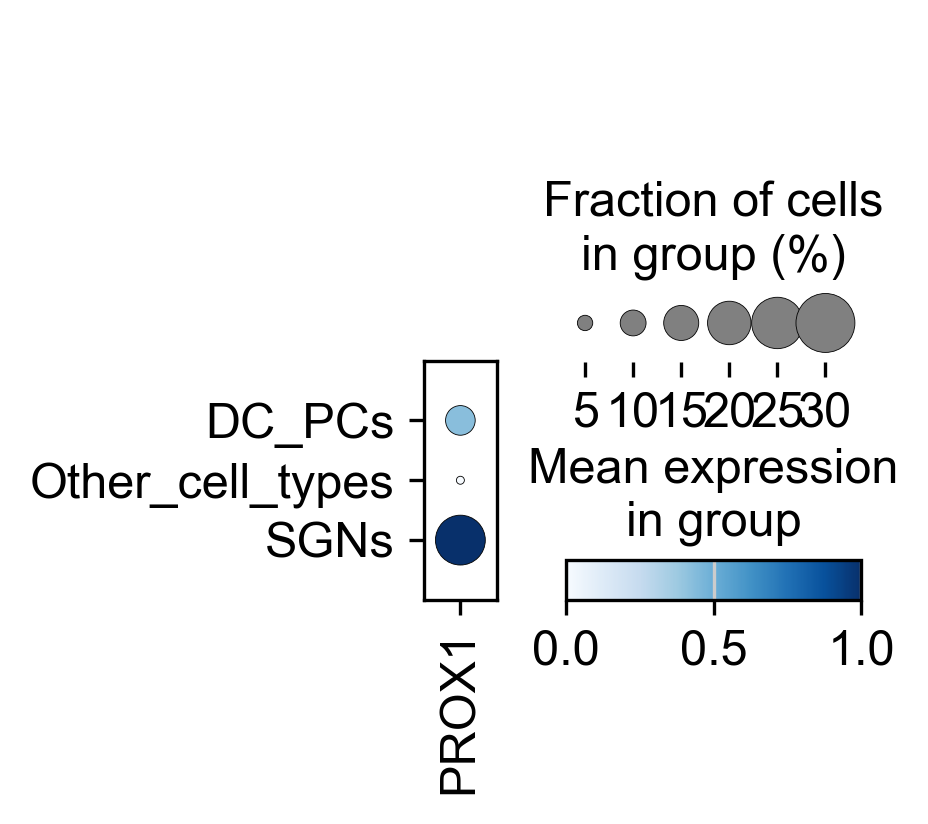

In [38]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(downsampled_adata,['PROX1',],
              groupby='cell_type_for_prox1',
              cmap='Blues',standard_scale='var',save='HUMAN_PROX1.pdf'
        )

In [39]:
# for esrrg ==sgn AND mc
# re-annotate
cluster_annotation = {
 'Basal_stria': 'Other_cell_types',
    'Claudius/Inner-Outer_sulcus_cells': 'Other_cell_types',
    'Deiters_cells/Pillar_cells': 'Other_cell_types',
    'Fibrocytes': 'Other_cell_types',
    'GCs': 'Other_cell_types',
  
    'Inner_border-phalangeal/Hensen_cells': 'Other_cell_types',
    'Interdental_cells': 'Other_cell_types',
    'Intermediate_stria': 'Other_cell_types',
    'Macrophages': 'Other_cell_types',
 
    'Marginal_stria': 'Ms',
    'HCs': 'Other_cell_types',

    'Osteocytes/Osteoblasts': 'Other_cell_types',
    'Endothelial_cells': 'Other_cell_types',
    
    'Reissner_membrane': 'Other_cell_types',
   
  
     'SGNs': 'SGNs',


    'SS': 'Other_cell_types',


    'Tympanic_border_cells': 'Other_cell_types',
}
downsampled_adata.obs['cell_type_for_esrrg'] = downsampled_adata.obs['cell_type_pyscenic'].map(cluster_annotation).astype('category')

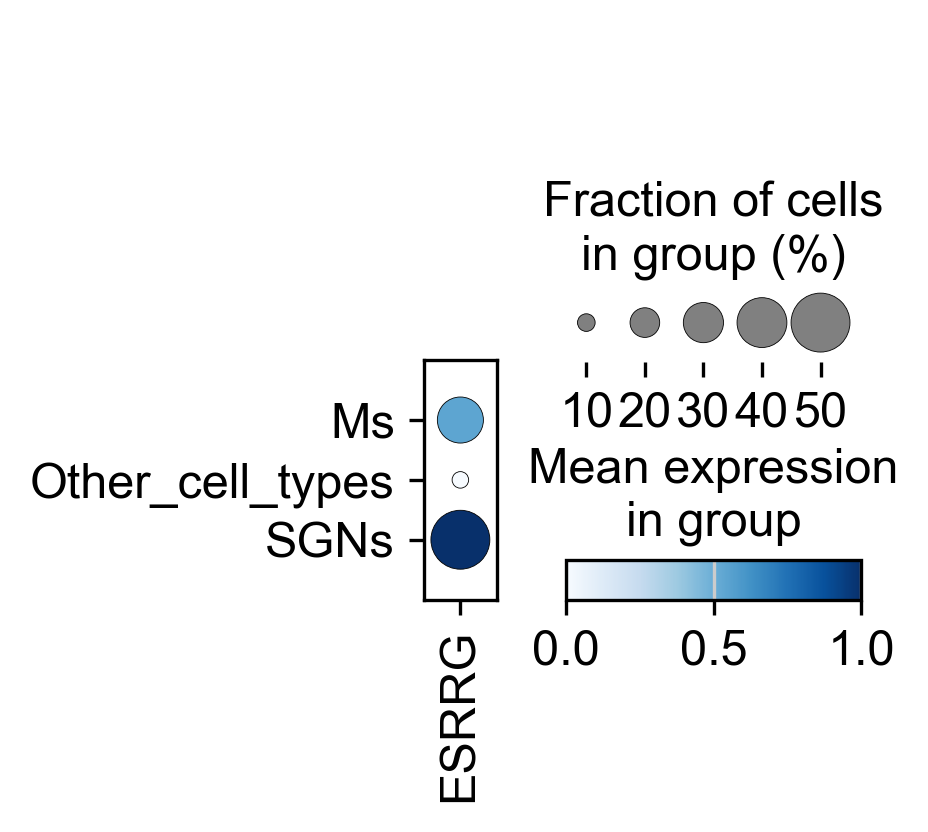

In [40]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(downsampled_adata,['ESRRG',],
              groupby='cell_type_for_esrrg',
              cmap='Blues',standard_scale='var',save='HUMAN_ESRRG.pdf'
        )

In [41]:
# for zeb2 ==gc IC AND macrophage
# re-annotate
cluster_annotation = {
 'Basal_stria': 'Other_cell_types',
    'Claudius/Inner-Outer_sulcus_cells': 'Other_cell_types',
    'Deiters_cells/Pillar_cells': 'DC_PCs',
    'Fibrocytes': 'Other_cell_types',
    'GCs': 'GCs',
  
    'Inner_border-phalangeal/Hensen_cells': 'Other_cell_types',
    'Interdental_cells': 'Other_cell_types',
    'Intermediate_stria': 'Other_cell_types',
    'Macrophages': 'Macrophages',
 
    'Marginal_stria': 'Ms',
    'HCs': 'Other_cell_types',

    'Osteocytes/Osteoblasts': 'Other_cell_types',
    'Endothelial_cells': 'Other_cell_types',
    
    'Reissner_membrane': 'Other_cell_types',
   
  
     'SGNs': 'SGNs',


    'SS': 'Other_cell_types',


    'Tympanic_border_cells': 'Other_cell_types',
}
downsampled_adata.obs['cell_type_for_zeb2'] = downsampled_adata.obs['cell_type_pyscenic'].map(cluster_annotation).astype('category')

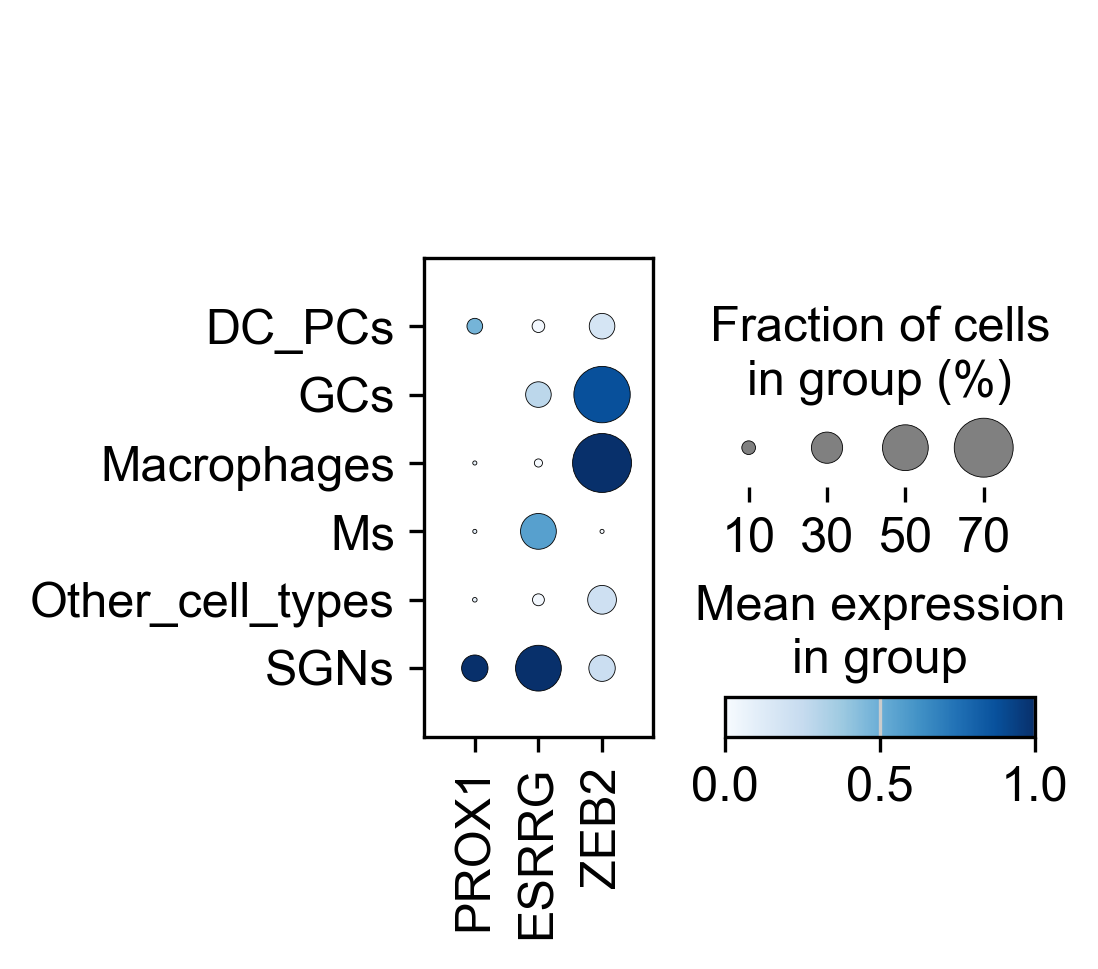

In [42]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(downsampled_adata,['PROX1','ESRRG','ZEB2',],
              groupby='cell_type_for_zeb2',
              cmap='Blues',standard_scale='var',save='HUMAN_ZEB2.pdf'
        )

In [51]:
adata1=sc.read("mouse_P25_1_rawcounts.h5ad")
adata2=sc.read("mouse_P25_2_rawcounts.h5ad")
adata3=sc.read("mouse_P28_1_rawcounts.h5ad")
adata4=sc.read("mouse_P28_2_rawcounts.h5ad")

In [52]:
adatas = adata1.concatenate(adata2,adata3,adata4)

In [53]:
adatas_HU_rm=sc.read('mouse_cochlea_P25_P28_scVI_with_rawounts.h5ad')

In [54]:
adata_new=adatas[adatas_HU_rm.obs.index]
adata_new

View of AnnData object with n_obs × n_vars = 17479 × 32285
    obs: 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'sequecing'
    var: 'gene_ids', 'feature_types', 'Gene', 'mt', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'n_cells_by_counts-3', 'mean_counts-3', 'pct_dropout_by_counts-3', 'total_counts-3'
    layers: 'counts', 'logcounts'

In [55]:
adata_new.X=adata_new.layers['counts']

In [56]:
adata=adatas_HU_rm.copy()
adata_new.obsm['X_pca']=adata.obsm['X_pca']
adata_new.obsm['X_scVI']=adata.obsm['X_scVI']
adata_new.obsm['X_umap']=adata.obsm['X_umap']
adata_new.uns['log1p']=adata.uns['log1p']
adata_new.uns['hvg']=adata.uns['hvg']
adata_new.uns['pca']=adata.uns['pca']
adata_new.uns['neighbors']=adata.uns['neighbors']
adata_new.uns['umap']=adata.uns['umap']
adata_new.uns['batch_colors']=adata.uns['batch_colors']
adata_new.uns['sequecing_colors']=adata.uns['sequecing_colors']
adata_new.uns['leiden_scanvi_1.2']=adata.uns['leiden_scanvi_1.2']
adata_new.var['gene_ids']=adata.var['gene_ids']
adata_new.var['feature_types']=adata.var['feature_types']
adata_new.var['Gene']=adata.var['Gene']
adata_new.obs['CellID']=adata.obs['CellID']
adata_new.obs['batch']=adata.obs['batch']
adata_new.obs['sequecing']=adata.obs['sequecing']
adata_new.obs['cell_type']=adata.obs['cell_type']
adata_new.obsp['connectivities']=adata.obsp['connectivities']
adata_new.obsp['distances']=adata.obsp['distances']

In [57]:
# to keep consistent cell-type for both mouse and human,we re-annotate and delect some type that only exist in either species
#remove root_cells spindle cells
exclude_clusters = ['Root_cells','Spindle_cells','Scala_vestibuli_border_cells']
adata_mu= adata_new[~adata_new.obs['cell_type'].isin(exclude_clusters), :]
adata_mu

View of AnnData object with n_obs × n_vars = 16232 × 32285
    obs: 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'sequecing', 'cell_type'
    var: 'gene_ids', 'feature_types', 'Gene', 'mt', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'n_cells_by_counts-3', 'mean_counts-3', 'pct_dropout_by_counts-3', 'total_counts-3'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'sequecing_colors', 'leiden_scanvi_1.2'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [58]:
# re-annotate
cluster_annotation = {
 'Basal_stria': 'Basal_stria',
    'Claudius/Inner-Outer_sulcus_cells': 'Claudius/Inner-Outer_sulcus_cells',
    'Dieters_cells/Pillar_cells': 'Deiters_cells/Pillar_cells',
    'Fibrocytes': 'Fibrocytes',
    'GCs': 'GCs',
    'IHCs': 'HCs',
    'Inner_border-phalangeal/Hensen_cells': 'Inner_border-phalangeal/Hensen_cells',
    'Interdental_cells': 'Interdental_cells',
    'Intermediate_stria': 'Intermediate_stria ',
    'Macrophages': 'Macrophages',
 
    'Marginal_cells': 'Marginal_stria',
    'OHCs': 'HCs',

    'Osteocytes/Osteoblasts': 'Osteocytes/Osteoblasts',
    'Pericytes/Endothelial_cells': 'Endothelial_cells',
    
    'Reissner_membrane': 'Reissner_membrane',
   
  
     'SGNs_1': 'SGNs',
     'SGNs_2': 'SGNs',

    'SS_1': 'SS',
    'SS_2': 'SS',

    'Tympanic_border_cells': 'Tympanic_border_cells',
    
   

    


}
adata_mu.obs['cell_type_pyscenic'] = adata_mu.obs['cell_type'].map(cluster_annotation).astype('category')

In [59]:
sc.pp.filter_genes(adata_mu, min_cells=1)
adata_mu

AnnData object with n_obs × n_vars = 16232 × 26473
    obs: 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'sequecing', 'cell_type', 'cell_type_pyscenic'
    var: 'gene_ids', 'feature_types', 'Gene', 'mt', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'n_cells_by_counts-3', 'mean_counts-3', 'pct_dropout_by_counts-3', 'total_counts-3', 'n_cells'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'sequecing_colors', 'leiden_scanvi_1.2'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [60]:
from sklearn.utils import resample
max_cells = 100


cells_to_keep = []


for cluster in adata_mu.obs['cell_type_pyscenic'].unique():
    
    cluster_cells = adata_mu.obs[adata_mu.obs['cell_type_pyscenic'] == cluster].index
    
    
    if len(cluster_cells) > max_cells:
        sampled_cells = resample(cluster_cells, 
                               replace=False, 
                               n_samples=max_cells, 
                               random_state=42)
        cells_to_keep.extend(sampled_cells)
    else:
        cells_to_keep.extend(cluster_cells)


downsampled_adata = adata_mu[cells_to_keep, :].copy()
downsampled_adata

AnnData object with n_obs × n_vars = 1668 × 26473
    obs: 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'sequecing', 'cell_type', 'cell_type_pyscenic'
    var: 'gene_ids', 'feature_types', 'Gene', 'mt', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'n_cells_by_counts-3', 'mean_counts-3', 'pct_dropout_by_counts-3', 'total_counts-3', 'n_cells'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'sequecing_colors', 'leiden_scanvi_1.2'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [61]:
#change alternative procedure
sc.pp.normalize_total(downsampled_adata, target_sum=1e4)
sc.pp.log1p(downsampled_adata)

In [62]:
# for IKZF2 AND GATA3 ==HC AND SC
# re-annotate
cluster_annotation = {
 'Basal_stria': 'Other_cell_types',
    'Claudius/Inner-Outer_sulcus_cells': 'SCs',
    'Deiters_cells/Pillar_cells': 'SCs',
    'Fibrocytes': 'Other_cell_types',
    'GCs': 'Other_cell_types',
  
    'Inner_border-phalangeal/Hensen_cells': 'SCs',
    'Interdental_cells': 'SCs',
    'Intermediate_stria': 'Other_cell_types',
    'Macrophages': 'Other_cell_types',
 
    'Marginal_stria': 'Other_cell_types',
    'HCs': 'HCs',

    'Osteocytes/Osteoblasts': 'Other_cell_types',
    'Endothelial_cells': 'Other_cell_types',
    
    'Reissner_membrane': 'Other_cell_types',
   
  
     'SGNs': 'Other_cell_types',


    'SS': 'Other_cell_types',


    'Tympanic_border_cells': 'Other_cell_types',
}
downsampled_adata.obs['cell_type_for_ikzf2_gata3'] = downsampled_adata.obs['cell_type_pyscenic'].map(cluster_annotation).astype('category')

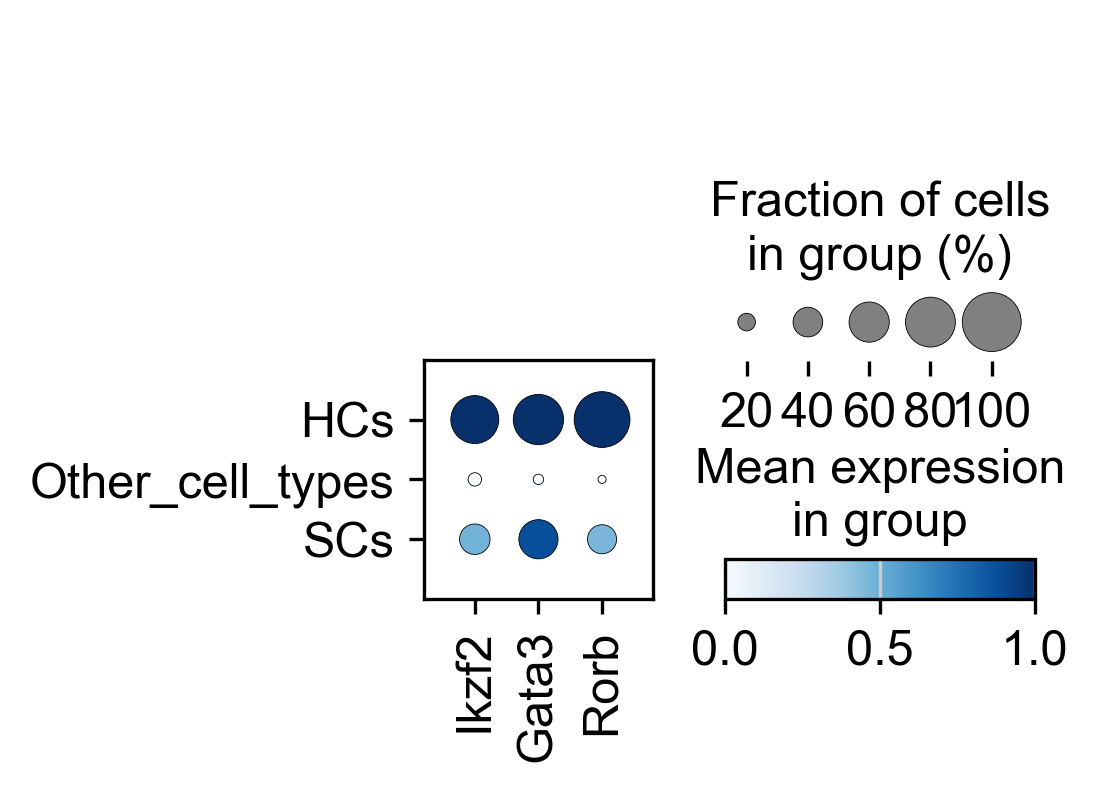

In [63]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(downsampled_adata,['Ikzf2','Gata3','Rorb'],
              groupby='cell_type_for_ikzf2_gata3',
              cmap='Blues',standard_scale='var',save='MOUSE_GATA3_IKZF2_RORB.pdf'
        )

In [64]:
# for prox1 ==sgn AND dc_pc
# re-annotate
cluster_annotation = {
 'Basal_stria': 'Other_cell_types',
    'Claudius/Inner-Outer_sulcus_cells': 'Other_cell_types',
    'Deiters_cells/Pillar_cells': 'DC_PCs',
    'Fibrocytes': 'Other_cell_types',
    'GCs': 'Other_cell_types',
  
    'Inner_border-phalangeal/Hensen_cells': 'Other_cell_types',
    'Interdental_cells': 'Other_cell_types',
    'Intermediate_stria': 'Other_cell_types',
    'Macrophages': 'Other_cell_types',
 
    'Marginal_stria': 'Other_cell_types',
    'HCs': 'Other_cell_types',

    'Osteocytes/Osteoblasts': 'Other_cell_types',
    'Endothelial_cells': 'Other_cell_types',
    
    'Reissner_membrane': 'Other_cell_types',
   
  
     'SGNs': 'SGNs',


    'SS': 'Other_cell_types',


    'Tympanic_border_cells': 'Other_cell_types',
}
downsampled_adata.obs['cell_type_for_prox1'] = downsampled_adata.obs['cell_type_pyscenic'].map(cluster_annotation).astype('category')

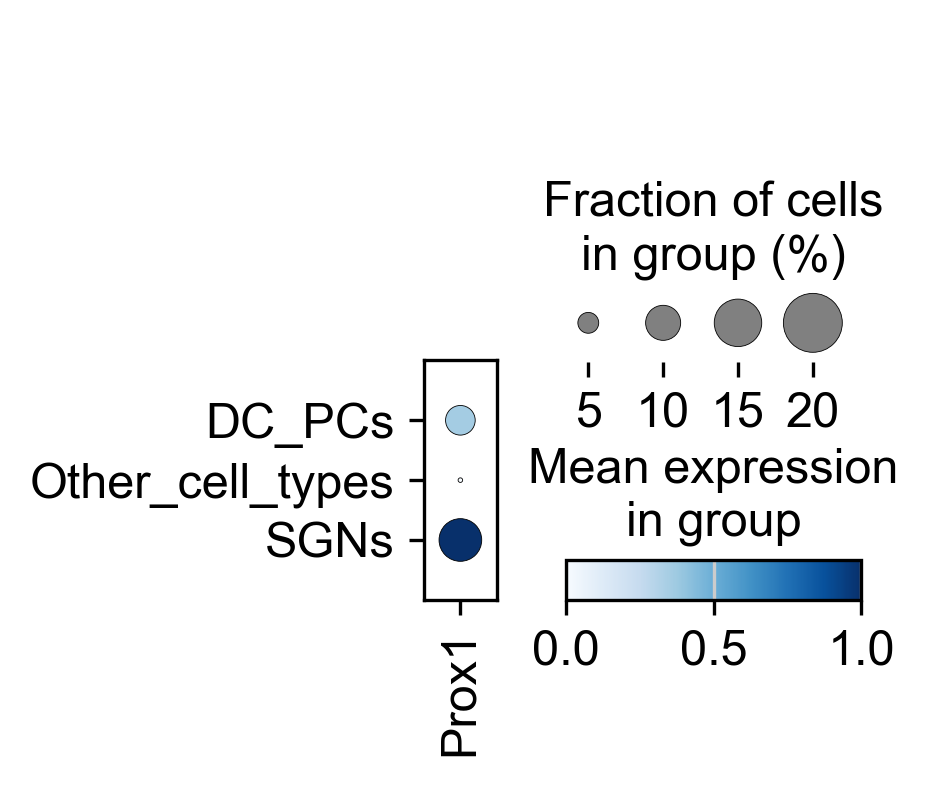

In [65]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(downsampled_adata,['Prox1',],
              groupby='cell_type_for_prox1',
              cmap='Blues',standard_scale='var',save='MOUSE_PROX1.pdf'
        )

In [66]:
# for esrrg ==sgn AND mc
# re-annotate
cluster_annotation = {
 'Basal_stria': 'Other_cell_types',
    'Claudius/Inner-Outer_sulcus_cells': 'Other_cell_types',
    'Deiters_cells/Pillar_cells': 'Other_cell_types',
    'Fibrocytes': 'Other_cell_types',
    'GCs': 'Other_cell_types',
  
    'Inner_border-phalangeal/Hensen_cells': 'Other_cell_types',
    'Interdental_cells': 'Other_cell_types',
    'Intermediate_stria': 'Other_cell_types',
    'Macrophages': 'Other_cell_types',
 
    'Marginal_stria': 'Ms',
    'HCs': 'Other_cell_types',

    'Osteocytes/Osteoblasts': 'Other_cell_types',
    'Endothelial_cells': 'Other_cell_types',
    
    'Reissner_membrane': 'Other_cell_types',
   
  
     'SGNs': 'SGNs',


    'SS': 'Other_cell_types',


    'Tympanic_border_cells': 'Other_cell_types',
}
downsampled_adata.obs['cell_type_for_esrrg'] = downsampled_adata.obs['cell_type_pyscenic'].map(cluster_annotation).astype('category')

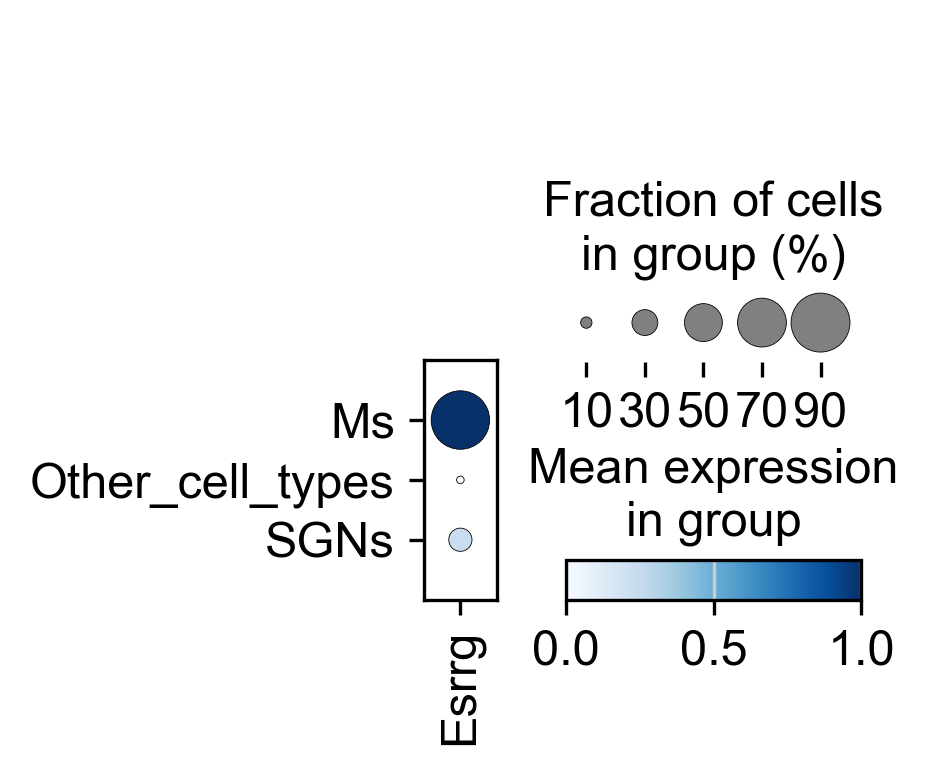

In [67]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(downsampled_adata,['Esrrg',],
              groupby='cell_type_for_esrrg',
              cmap='Blues',standard_scale='var',save='MOUSE_ESRRG.pdf'
        )

In [68]:
# for zeb2 ==gc IC AND macrophage
# re-annotate
cluster_annotation = {
 'Basal_stria': 'Other_cell_types',
    'Claudius/Inner-Outer_sulcus_cells': 'Other_cell_types',
    'Deiters_cells/Pillar_cells': 'DC_PCs',
    'Fibrocytes': 'Other_cell_types',
    'GCs': 'GCs',
  
    'Inner_border-phalangeal/Hensen_cells': 'Other_cell_types',
    'Interdental_cells': 'Other_cell_types',
    'Intermediate_stria': 'Other_cell_types',
    'Macrophages': 'Macrophages',
 
    'Marginal_stria': 'Ms',
    'HCs': 'Other_cell_types',

    'Osteocytes/Osteoblasts': 'Other_cell_types',
    'Endothelial_cells': 'Other_cell_types',
    
    'Reissner_membrane': 'Other_cell_types',
   
  
     'SGNs': 'SGNs',


    'SS': 'Other_cell_types',


    'Tympanic_border_cells': 'Other_cell_types',
}
downsampled_adata.obs['cell_type_for_zeb2'] = downsampled_adata.obs['cell_type_pyscenic'].map(cluster_annotation).astype('category')

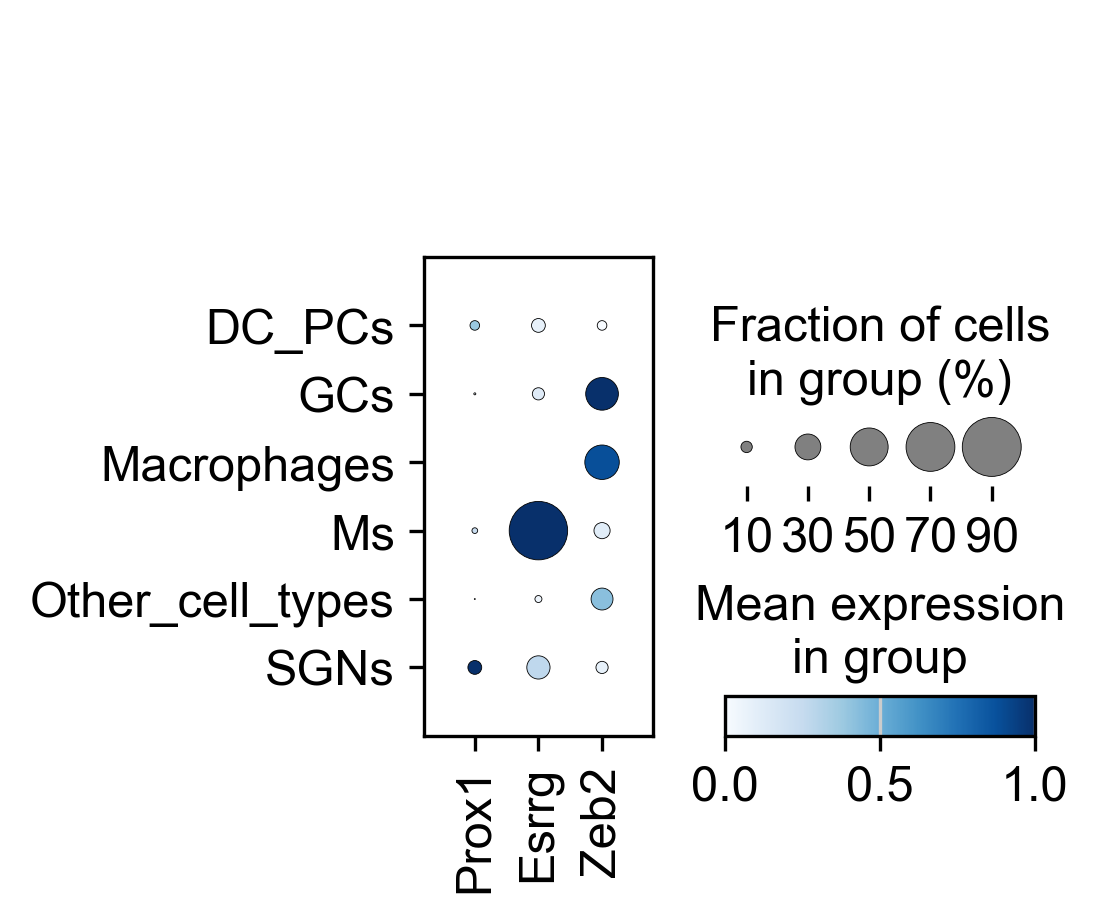

In [69]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(downsampled_adata,['Prox1','Esrrg','Zeb2',],
              groupby='cell_type_for_zeb2',
              cmap='Blues',standard_scale='var',save='MOUSE_ZEB2.pdf'
        )